In [1]:
import scanpy as sc
import os

VISIUM_DIR = "/Users/adiallo/Desktop/Thesis/Data_Documents/All_Data/Visium_samples/Visium_Data/samples"

# numeric .h5ad files only
visium_files = sorted(
    f for f in os.listdir(VISIUM_DIR)
    if f.endswith(".h5ad") and f.replace(".h5ad","").isdigit()
)

len(visium_files), visium_files[:5]

(41, ['0.h5ad', '10.h5ad', '100.h5ad', '102.h5ad', '106.h5ad'])

In [4]:
for f in visium_files:
    adata = sc.read_h5ad(os.path.join(VISIUM_DIR, f))
    print(f, adata.shape)

0.h5ad (6658, 13598)
10.h5ad (6138, 13598)
100.h5ad (7194, 13598)
102.h5ad (6847, 13598)
106.h5ad (7088, 13598)
107.h5ad (7057, 13598)
11.h5ad (7353, 13598)
111.h5ad (7046, 13598)
116.h5ad (8238, 13598)
117.h5ad (4778, 13598)
119.h5ad (7191, 13598)
122.h5ad (5903, 13598)
127.h5ad (7173, 13598)
128.h5ad (6661, 13598)
13.h5ad (5910, 13598)
14.h5ad (6855, 13598)
18.h5ad (6319, 13598)
28.h5ad (6989, 13598)
29.h5ad (6768, 13598)
3.h5ad (5571, 13598)
30.h5ad (6476, 13598)
34.h5ad (6297, 13598)
36.h5ad (6873, 13598)
38.h5ad (6971, 13598)
40.h5ad (7217, 13598)
46.h5ad (6826, 13598)
49.h5ad (6502, 13598)
51.h5ad (6342, 13598)
52.h5ad (6718, 13598)
6.h5ad (6414, 13598)
60.h5ad (6492, 13598)
72.h5ad (6706, 13598)
73.h5ad (6532, 13598)
74.h5ad (7010, 13598)
80.h5ad (6526, 13598)
81.h5ad (7274, 13598)
83.h5ad (7485, 13598)
86.h5ad (7480, 13598)
91.h5ad (6651, 13598)
96.h5ad (6987, 13598)
97.h5ad (6142, 13598)


In [2]:
import scanpy as sc
import pandas as pd
import os

VISIUM_DIR = "/Users/adiallo/Desktop/Thesis/Data_Documents/All_Data/Visium_samples/Visium_Data/samples"
META_PATH  = "/Users/adiallo/Desktop/Thesis/Data_Documents/data_all.csv"

meta = pd.read_csv(META_PATH)
meta["deident"] = meta["deident"].astype(str)

def classify_mets(row):
    # row fields look like T/F and TRUE/FALSE depending on how pandas read them
    any_mets = str(row["any_mets"]).strip().upper() in ["T", "TRUE", "1"]
    ln_only  = str(row["ln_only"]).strip().upper() in ["T", "TRUE", "1"]
    dist     = str(row["Distant_Mets"]).strip().upper() in ["T", "TRUE", "1"]

    if not any_mets:
        return "No"
    if dist:
        return "Distant"
    # if any_mets but not distant, treat as LN (ln_only should usually be True here)
    return "LN"

# numeric .h5ad files only
visium_files = sorted(
    f for f in os.listdir(VISIUM_DIR)
    if f.endswith(".h5ad") and f.replace(".h5ad","").isdigit()
)

adata_list = []

for f in visium_files:
    sample_id = f.replace(".h5ad","")  # e.g. "127"
    adata = sc.read_h5ad(os.path.join(VISIUM_DIR, f))

    row = meta.loc[meta["deident"] == sample_id]
    if row.shape[0] != 1:
        raise ValueError(f"Expected 1 metadata row for deident={sample_id}, found {row.shape[0]}")
    row = row.iloc[0]

    adata.obs["patient_id"]  = sample_id
    adata.obs["mets_status"] = classify_mets(row)
    adata.obs["MLH1"]        = row["MLH1"]
    adata.obs["age"]         = row["age"]
    adata.obs["sex"]         = row["sex"]

    adata_list.append(adata)

# quick check
adata_list[0].obs[["patient_id","mets_status","MLH1","age","sex"]].head()

,patient_id,mets_status,MLH1,age,sex
AACAATCCGAGTGGAC-1,0,LN,1,62,M
AACAATGTGCTCCGAG-1,0,LN,1,62,M
AACACGACAACGGAGT-1,0,LN,1,62,M
AACACGACAATTGTTC-1,0,LN,1,62,M
AACACGGAACGAGTTA-1,0,LN,1,62,M


In [6]:
meta[["deident","any_mets","ln_only","Distant_Mets"]].head(10)

,deident,any_mets,ln_only,Distant_Mets
0,0,T,T,False
1,2,T,F,True
2,3,F,F,False
3,6,T,F,True
4,10,F,F,False
5,11,T,F,True
6,13,F,F,False
7,14,F,F,False
8,18,T,F,True
9,19,F,F,False


In [7]:
#Test one sample

In [4]:
# pick one sample to inspect
adata = adata_list[0]

# list all Cell2Location columns
abundance_cols = adata.obsm["means_cell_abundance_w_sf"].columns
abundance_cols[:10]

Index(['meanscell_abundance_w_sf_Tumor_cE01 (Stem/TA-like)',
       'meanscell_abundance_w_sf_Tumor_cE02 (Stem/TA-like/Immature Goblet)',
       'meanscell_abundance_w_sf_Tumor_cE03 (Stem/TA-like prolif)',
       'meanscell_abundance_w_sf_Tumor_cE04 (Enterocyte 1)',
       'meanscell_abundance_w_sf_Tumor_cE05 (Enterocyte 2)',
       'meanscell_abundance_w_sf_Tumor_cE06 (Immature Goblet)',
       'meanscell_abundance_w_sf_Tumor_cE07 (Goblet/Enterocyte)',
       'meanscell_abundance_w_sf_Tumor_cE08 (Goblet)',
       'meanscell_abundance_w_sf_Tumor_cE09 (Best4)',
       'meanscell_abundance_w_sf_Tumor_cE10 (Tuft)'],
      dtype='object')

In [5]:
[c for c in abundance_cols if "cM03" in c]

['meanscell_abundance_w_sf_cM03 (DC1)']

In [6]:
adata = adata_list[0]

abundance_cols = adata.obsm["means_cell_abundance_w_sf"].columns

dc_cols = [c for c in abundance_cols if "(DC" in c or "pDC" in c or "mregDC" in c]

dc_cols

['meanscell_abundance_w_sf_cM03 (DC1)',
 'meanscell_abundance_w_sf_cM04 (DC2)',
 'meanscell_abundance_w_sf_cM05 (DC2 C1Q+)',
 'meanscell_abundance_w_sf_cM06 (DC IL22RA2)',
 'meanscell_abundance_w_sf_cM07 (pDC)',
 'meanscell_abundance_w_sf_cM09 (mregDC)']

In [23]:
import pandas as pd

dc1_key = "cM03"  # DC1

rows = []

for adata in adata_list:
    ab = adata.obsm["means_cell_abundance_w_sf"]
    dc2_col = [c for c in ab.columns if dc2_key in c][0]   # exact column name

    obs = adata.obs.copy()

    # add DC2 abundance
    obs["DC1_abundance"] = ab[dc2_col].values

    # keep only columns we need (region column added in next line once we find it)
    keep = ["patient_id", "mets_status", "MLH1", "DC1_abundance"]
    keep = [k for k in keep if k in obs.columns]  # safe

    rows.append(obs[keep])

dc2_spots = pd.concat(rows, axis=0)

dc2_spots.shape, dc2_spots.head()

((275658, 4),
                    patient_id mets_status  MLH1  DC1_abundance
 AACAATCCGAGTGGAC-1          0          LN     1       0.092786
 AACAATGTGCTCCGAG-1          0          LN     1       0.039421
 AACACGACAACGGAGT-1          0          LN     1       0.040000
 AACACGACAATTGTTC-1          0          LN     1       0.094066
 AACACGGAACGAGTTA-1          0          LN     1       0.152838)

In [8]:
adata_list[0].obs.columns

Index(['in_tissue', 'array_row', 'array_col', '_indices', '_scvi_batch',
       '_scvi_labels', 'histology', 'patient_id', 'mets_status', 'MLH1', 'age',
       'sex'],
      dtype='object')

In [24]:
rows = []

for adata in adata_list:
    ab = adata.obsm["means_cell_abundance_w_sf"]
    dc2_col = [c for c in ab.columns if "cM03" in c][0]

    obs = adata.obs.copy()
    obs["DC1_abundance"] = ab[dc2_col].values

    keep = ["patient_id", "mets_status", "MLH1", "histology", "DC1_abundance"]
    rows.append(obs[keep])

dc1_spots = pd.concat(rows, axis=0)

dc1_spots.head()

,patient_id,mets_status,MLH1,histology,DC1_abundance
AACAATCCGAGTGGAC-1,0,LN,1,cancer_cancer,0.092786
AACAATGTGCTCCGAG-1,0,LN,1,Unannotated,0.039421
AACACGACAACGGAGT-1,0,LN,1,cancer_cancer,0.040000
AACACGACAATTGTTC-1,0,LN,1,cancer_cancer,0.094066
AACACGGAACGAGTTA-1,0,LN,1,cancer_cancer,0.152838


In [10]:
dc1_spots["histology"].value_counts()

histology
cancer_cancer          171669
benign_muscularis       22967
inter                   19630
benign_fat              18369
benign_stroma           14037
Unannotated              9699
benign_epithelium        8856
benign_submucosa         7163
benign_inflammation      2918
benign_serosa             350
Name: count, dtype: int64

In [12]:
dc1_spots.groupby("histology")["DC1_abundance"].describe()

,count,mean,std,min,25%,50%,75%,max
histology,,,,,,,,
Unannotated,9699.0,0.062378,0.041537,0.025380,0.041240,0.049827,0.062888,0.453989
benign_epithelium,8856.0,0.065381,0.039595,0.024339,0.046106,0.052083,0.065602,0.410562
benign_fat,18369.0,0.046134,0.021928,0.028153,0.036279,0.040512,0.047594,0.421237
benign_inflammation,2918.0,0.171235,0.087407,0.031662,0.088101,0.176705,0.242765,0.539921
benign_muscularis,22967.0,0.056847,0.022829,0.027472,0.045305,0.051857,0.060332,0.404013
benign_serosa,350.0,0.050885,0.016252,0.032292,0.041644,0.046744,0.052807,0.154783
benign_stroma,14037.0,0.062328,0.039400,0.029418,0.042499,0.049674,0.063482,0.648284
benign_submucosa,7163.0,0.051555,0.021025,0.031098,0.041249,0.047604,0.055447,0.410587
cancer_cancer,171669.0,0.088700,0.049807,0.024712,0.053157,0.071061,0.111561,0.554382


In [25]:
def define_regions_spatial(adata, pixel_scale_100um):
    coords = adata.obsm["spatial"]
    
    # 1. Labels from your successful script
    tumor_labels = ["cancer_cancer"] 
    stroma_labels = ["benign_stroma", "benign_fat", "inter", "stroma"] 

    histo = adata.obs["histology"].astype(str)
    is_tumor = histo.isin(tumor_labels).values
    is_stroma = histo.isin(stroma_labels).values
    
    # Early exit if one component is missing
    if sum(is_tumor) == 0: return np.array(["Other"] * adata.n_obs)
    if sum(is_stroma) == 0: return np.where(is_tumor, "Center Tumor (CT)", "Other")

    # --- STEP 1: FIND THE BIOLOGICAL INTERFACE ---
    tumor_coords = coords[is_tumor]
    stroma_tree = KDTree(coords[is_stroma])
    
    # Find distance from every tumor spot to the nearest stroma spot
    dists_to_stroma, _ = stroma_tree.query(tumor_coords, k=1)
    
    # Threshold for being "at the edge" (1.5 spots)
    neighbor_threshold = 1.5 * pixel_scale_100um
    boundary_subset_mask = dists_to_stroma <= neighbor_threshold
    
    tumor_indices = np.where(is_tumor)[0]
    true_boundary_indices = tumor_indices[boundary_subset_mask]
    
    if len(true_boundary_indices) == 0:
        return np.where(is_tumor, "Center Tumor (CT)", "Other")
        
    # --- STEP 2: DEFINE ZONES BASED ON THAT INTERFACE ---
    boundary_coords = coords[true_boundary_indices]
    boundary_tree = KDTree(boundary_coords)
    dists_to_boundary, _ = boundary_tree.query(coords)
    
    # Define width (500um = ~5 spots)
    im_width_pixels = 5 * pixel_scale_100um
    is_proximal = dists_to_boundary <= im_width_pixels
    
    region_labels = np.array(["Other"] * adata.n_obs, dtype=object)
    
    # Assign IM: Tumor/Stroma spots near the TRUE boundary
    region_labels[is_proximal & (is_tumor | is_stroma)] = "Invasive Margin (IM)"
    
    # Assign CT: Tumor spots NOT in the margin
    region_labels[is_tumor & (~is_proximal)] = "Center Tumor (CT)"
    
    return region_labels

In [16]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
from scipy.spatial import KDTree

for adata in adata_list:
    # A. Calculate scale dynamically for each sample
    coords = adata.obsm["spatial"]
    nbrs = NearestNeighbors(n_neighbors=2).fit(coords)
    distances, _ = nbrs.kneighbors(coords)
    pixel_scale_100um = np.median(distances[:, 1]) 
    
    # B. Apply the two-step logic
    adata.obs["region"] = define_regions_spatial(adata, pixel_scale_100um)

In [26]:
# Check if CT is now present
print(adata_list[0].obs["region"].value_counts())

region
Center Tumor (CT)       2901
Other                   2449
Invasive Margin (IM)    1308
Name: count, dtype: int64


/var/folders/pt/fnxwl25d6cj484ywz_9by07w0000gq/T/ipykernel_6225/1881597030.py:15: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


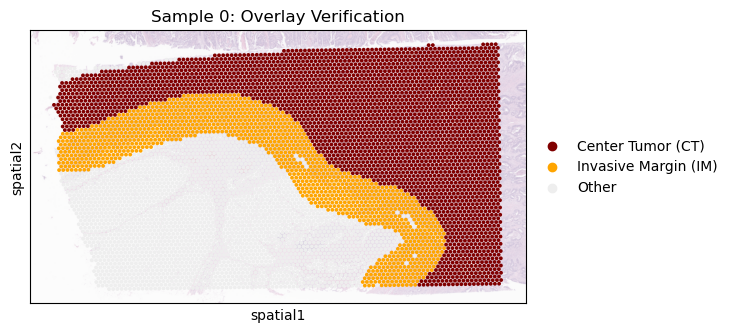

In [27]:
import scanpy as sc
import matplotlib.pyplot as plt

# 1. Identify the library ID (Scanpy needs this to link obs to the image)
library_id = list(adata_list[0].uns['spatial'].keys())[0]

# 2. Define the palette
region_palette = {
    "Center Tumor (CT)": "maroon",
    "Invasive Margin (IM)": "orange",
    "Other": "#eeeeee"
}

# 3. Plot with explicit spot parameters
sc.pl.spatial(
    adata_list[0],
    library_id=library_id,
    color="region",
    palette=region_palette,
    size=1.5,            # Increase if spots are too small
    img_key="hires",      # Ensures it uses the high-res background
    alpha_img=0.5,        # Fades the H&E slightly so spots "pop"
    title="Sample 0: Overlay Verification",
    show=True
)

In [19]:
import anndata as ad
import pandas as pd
import numpy as np
import scanpy as sc

# Column key for DC2
dc1_key = "cM03"

all_adatas = []

for adata in adata_list:

    # --------------------------------------------------
    # A. Extract DC1 abundance (continuous, no threshold)
    # --------------------------------------------------
    ab = adata.obsm["means_cell_abundance_w_sf"]
    dc1_col = [c for c in ab.columns if dc1_key in c][0]
    adata.obs["DC1_abundance"] = ab[dc1_col].values

    # --------------------------------------------------
    # B. Define a simple QC covariate (total counts)
    # --------------------------------------------------
    if "total_counts" not in adata.obs.columns:
        sc.pp.calculate_qc_metrics(adata, inplace=True)

    adata.obs["QC"] = np.log1p(adata.obs["total_counts"])

    # --------------------------------------------------
    # C. Standardize metadata types
    # --------------------------------------------------
    adata.obs["region"] = adata.obs["region"].astype(str)
    adata.obs["mets_status"] = adata.obs["mets_status"].astype(str)
    adata.obs["patient_id"] = adata.obs["patient_id"].astype(str)
    adata.obs["MLH1"] = adata.obs["MLH1"].astype(int)

    # --------------------------------------------------
    # D. KEEP ONLY CT + IM (drop "Other")
    # --------------------------------------------------
    adata = adata[
        adata.obs["region"].isin(["Center Tumor (CT)", "Invasive Margin (IM)"])
    ].copy()

    all_adatas.append(adata)

# ------------------------------------------------------
# E. Concatenate all samples (shared genes only)
# ------------------------------------------------------
adata_all_spots = ad.concat(all_adatas, join="inner")

# ------------------------------------------------------
# F. Set reference levels explicitly
# ------------------------------------------------------
adata_all_spots.obs["region"] = pd.Categorical(
    adata_all_spots.obs["region"],
    categories=["Center Tumor (CT)", "Invasive Margin (IM)"]
)

adata_all_spots.obs["mets_status"] = pd.Categorical(
    adata_all_spots.obs["mets_status"],
    categories=["No", "LN", "Distant"]  # adjust ONLY if your labels differ
)

print(
    f"Ready for MAST: "
    f"{adata_all_spots.n_obs} spots, "
    f"{adata_all_spots.n_vars} genes"
)

Ready for MAST: 186146 spots, 13598 genes


/opt/anaconda3/envs/visium/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [20]:
# Check spot distribution across the two primary factors
print(pd.crosstab(adata_all_spots.obs["region"], adata_all_spots.obs["mets_status"]))

# Check that every patient has at least some spots in both regions
# (MAST can struggle if a patient is 100% CT or 100% IM)
patient_region_check = pd.crosstab(adata_all_spots.obs["patient_id"], adata_all_spots.obs["region"])
print(patient_region_check.head())

mets_status              No     LN  Distant
region                                     
Center Tumor (CT)     67167  38814    44187
Invasive Margin (IM)  15503  10665     9810
region      Center Tumor (CT)  Invasive Margin (IM)
patient_id                                         
0                        2901                  1308
10                       3400                   585
100                      6992                   168
102                       687                     0
106                      4256                  1103


In [21]:
import scipy.sparse as sp
from scipy import io  # Explicitly import the io submodule

# 1. Identify and keep only patients with both CT and IM regions
region_counts = pd.crosstab(adata_all_spots.obs["patient_id"], adata_all_spots.obs["region"])
valid_patients = region_counts[(region_counts["Center Tumor (CT)"] > 0) & 
                               (region_counts["Invasive Margin (IM)"] > 0)].index

adata_final = adata_all_spots[adata_all_spots.obs["patient_id"].isin(valid_patients)].copy()

# 2. CRITICAL: Make observation names unique
# Since spots from different samples often have the same barcodes (e.g., AA...-1),
# this appends a suffix so every spot has a unique ID in R.
adata_final.obs_names_make_unique()

# 3. Export Metadata and Gene Info
adata_final.obs.to_csv("/Users/adiallo/Desktop/Thesis/Data_Documents/All_Data/Visium_samples/Visium_Data/samples/DC1_mast_metadata.csv")
adata_final.var.to_csv("/Users/adiallo/Desktop/Thesis/Data_Documents/All_Data/Visium_samples/Visium_Data/samples/DC1_mast_gene_info.csv")

# 4. Export Sparse Expression Matrix
# Now using the explicitly imported io module
io.mmwrite("/Users/adiallo/Desktop/Thesis/Data_Documents/All_Data/Visium_samples/Visium_Data/samples/DC1_mast_counts.mtx", adata_final.X.T)

/opt/anaconda3/envs/visium/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
